# Домашняя работа 1 — Бенчмарк форматов хранения данных

**Датасет:** Amazon Reviews 2023 (Books) — отзывы покупателей с Amazon за 1996–2023 годы.  
Полный файл категории Books занимает около **18.7 GB**. В работе используется **15 млн строк**, чтобы закрыть требование работы с данными больше 10 GB.

**Источник:** https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

### Описание признаков (features)

| Признак | Тип | Описание |
|---|---|---|
| `rating` | float | Оценка товара от 1.0 до 5.0 |
| `title` | str | Краткий заголовок отзыва |
| `text` | str | Полный текст отзыва |
| `asin` | str | Уникальный ID товара на Amazon |
| `parent_asin` | str | ID родительского товара |
| `user_id` | str | Анонимизированный ID автора отзыва |
| `timestamp` | datetime | Дата и время публикации отзыва |
| `helpful_vote` | int | Количество голосов "полезный отзыв" |
| `verified_purchase` | bool | Подтверждённая покупка |

**Целевой признак:** `rating` — оценка товара, которую ставит покупатель.




In [1]:
!pip install pyarrow fastparquet duckdb polars sqlalchemy orjson ujson ijson numba -q


In [2]:
# standard library
import csv
import gc
import glob
import heapq
import json
import os
import sqlite3
import time
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from typing import Any, Callable, Dict, Iterable, List, Tuple

import requests
from requests.exceptions import ChunkedEncodingError, ConnectionError as ReqConnErr

# data processing
import duckdb
import numpy as np
import pandas as pd
import polars as pl
import pyarrow.compute as pc
import pyarrow.parquet as pq
from sqlalchemy import create_engine, text

# json parsers
import ijson
import orjson
import ujson

# JIT compilation
from numba import njit

# visualization
import matplotlib.pyplot as plt


In [3]:
DATASET_URL: str = (
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/"
    "resolve/main/raw/review_categories/Books.jsonl"
)
TARGET_ROWS: int = 15_000_000
CHUNK_SIZE: int = 100_000


## 1. Загрузка и подготовка данных

In [4]:
r = requests.head(DATASET_URL, allow_redirects=True)
size_gb = int(r.headers.get("Content-Length", 0)) / (1024**3)
print(f"Full file size: {size_gb:.1f} GB")

Full file size: 18.7 GB


In [5]:
# Resumable download — survives connection drops without external storage.
# Strategy:
#   - download in 1M-row chunks
#   - persist each chunk as a parquet file in ./chunks/ (local working dir)
#   - on re-run, scan ./chunks/ and continue from the next missing chunk
#   - merge all chunks into one parquet via streaming ParquetWriter
#     (does NOT load all chunks into RAM at once)
CHUNK_ROWS: int = 1_000_000
CHUNKS_DIR: str = "chunks"
DATA_PARQUET: str = "data.parquet"
os.makedirs(CHUNKS_DIR, exist_ok=True)


def merge_chunks_streaming(chunk_paths, out_path):
    """Merge multiple parquet chunks into one file without loading all into RAM."""
    writer = None
    for i, path in enumerate(chunk_paths, 1):
        table = pq.read_table(path)
        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema, compression="snappy")
        writer.write_table(table)
        del table
        gc.collect()
        print(f"  merged chunk {i}/{len(chunk_paths)}")
    if writer:
        writer.close()


# Fast path: final merged parquet already exists -> just load it.
if os.path.exists(DATA_PARQUET):
    df = pd.read_parquet(DATA_PARQUET)
    if "images" in df.columns:
        df = df.drop(columns=["images"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["rating"] = df["rating"].astype("float32")
    print(f"Loaded existing parquet: {len(df):,} rows from {DATA_PARQUET}")
else:
    existing_chunks = sorted(glob.glob(os.path.join(CHUNKS_DIR, "chunk_*.parquet")))
    chunks_done = len(existing_chunks)
    rows_already = chunks_done * CHUNK_ROWS
    print(f"Found {chunks_done} existing chunks ({rows_already:,} rows)")

    target_chunks = TARGET_ROWS // CHUNK_ROWS
    max_retries_per_chunk = 5

    while chunks_done < target_chunks:
        chunk_buffer: List[dict] = []
        skip_n = chunks_done * CHUNK_ROWS
        attempt = 0

        while len(chunk_buffer) < CHUNK_ROWS and attempt < max_retries_per_chunk:
            attempt += 1
            try:
                seen = 0
                with requests.get(DATASET_URL, stream=True, timeout=120) as r:
                    r.raise_for_status()
                    for line in r.iter_lines():
                        if not line:
                            continue
                        if seen < skip_n + len(chunk_buffer):
                            seen += 1
                            continue
                        chunk_buffer.append(json.loads(line))
                        seen += 1
                        if len(chunk_buffer) >= CHUNK_ROWS:
                            break
                if len(chunk_buffer) >= CHUNK_ROWS:
                    break
            except (ChunkedEncodingError, ReqConnErr,
                    requests.exceptions.ReadTimeout) as e:
                print(f"    [chunk {chunks_done + 1}, retry {attempt}/{max_retries_per_chunk}] "
                      f"{type(e).__name__}; reconnecting...")
                time.sleep(2)
                continue

        if len(chunk_buffer) < CHUNK_ROWS:
            raise RuntimeError(
                f"Failed to download chunk {chunks_done + 1} after "
                f"{max_retries_per_chunk} retries"
            )

        os.makedirs(CHUNKS_DIR, exist_ok=True)
        chunk_path = os.path.join(CHUNKS_DIR, f"chunk_{chunks_done:03d}.parquet")
        pd.DataFrame(chunk_buffer).to_parquet(chunk_path, compression="snappy")
        chunks_done += 1
        print(f"  saved chunk {chunks_done}/{target_chunks} -> {chunk_path}")

    # Streaming merge — never holds all chunks in RAM
    print(f"\nMerging {chunks_done} chunks (streaming) ...")
    chunk_paths = sorted(glob.glob(os.path.join(CHUNKS_DIR, "chunk_*.parquet")))
    merge_chunks_streaming(chunk_paths, DATA_PARQUET)

    # Re-read merged parquet, fix dtypes, drop unused cols
    print("Loading merged parquet and fixing dtypes ...")
    df = pd.read_parquet(DATA_PARQUET)
    if "images" in df.columns:
        df = df.drop(columns=["images"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df["rating"] = df["rating"].astype("float32")

    # Re-write with correct dtypes
    df.to_parquet(DATA_PARQUET, compression="snappy", index=False)
    print(f"Saved final parquet: {len(df):,} rows -> {DATA_PARQUET}")

print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / (1024**3):.2f} GB")
print(f"Columns: {list(df.columns)}")
df.head(5)

Loaded existing parquet: 15,000,000 rows from data.parquet

Memory usage: 11.95 GB
Columns: ['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1.0,Not a watercolor book! Seems like copies imo.,It is definitely not a watercolor book. The p...,B09BGPFTDB,B09BGPFTDB,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-01-17 06:06:38.485,0,True
1,5.0,Updated: after 1st arrived damaged this one is...,Updated: after first book arrived very damaged...,0593235657,0593235657,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-12-27 18:26:44.904,1,True
2,5.0,Excellent! I love it!,I bought it for the bag on the front so it pai...,1782490671,1782490671,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-12-24 22:04:55.102,0,True
3,5.0,Updated after 1st arrived damaged. Excellent,Updated: after 1st arrived damaged the replace...,0593138228,0593138228,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-12-24 16:55:06.602,0,False
4,5.0,Beautiful patterns!,I love this book! The patterns are lovely. I ...,0823098079,0823098079,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-11-19 08:57:33.230,0,True


## 2. Бенчмарк записи в разные форматы

Сохраняем один и тот же DataFrame в 7 форматов и замеряем wall-time и cpu-time.

In [6]:
results_write = []


def file_size_gb(path: str) -> float:
    return os.path.getsize(path) / (1024**3) if os.path.exists(path) else 0.0


def bench_write(name: str, path: str, func: Callable[[], None]) -> None:
    if os.path.exists(path):
        os.remove(path)
    gc.collect()
    t0_wall = time.time()
    t0_cpu = time.process_time()
    func()
    wall = time.time() - t0_wall
    cpu = time.process_time() - t0_cpu
    size = file_size_gb(path)
    results_write.append({
        "format": name,
        "wall_time": round(wall, 2),
        "cpu_time": round(cpu, 2),
        "size_gb": round(size, 2),
    })
    print(f"{name:10s} | wall: {wall:8.2f}s | cpu: {cpu:8.2f}s | size: {size:.2f} GB")


def iter_df_chunks() -> Iterable[pd.DataFrame]:
    for start in range(0, len(df), CHUNK_SIZE):
        chunk = df.iloc[start:start + CHUNK_SIZE].copy()
        chunk["timestamp"] = chunk["timestamp"].astype(str)
        yield chunk
        del chunk
        gc.collect()


def write_csv_stream(path: str, sep: str = ",") -> None:
    first = True
    for chunk in iter_df_chunks():
        chunk.to_csv(path, mode="w" if first else "a", header=first, index=False, sep=sep)
        first = False


def write_json_array_stream(path: str) -> None:
    first_record = True
    with open(path, "wb") as file_obj:
        file_obj.write(b"[\n")
        for chunk in iter_df_chunks():
            for record in chunk.to_dict(orient="records"):
                if not first_record:
                    file_obj.write(b",\n")
                file_obj.write(orjson.dumps(record))
                first_record = False
        file_obj.write(b"\n]")


def write_jsonl_stream(path: str) -> None:
    with open(path, "wb") as file_obj:
        for chunk in iter_df_chunks():
            for record in chunk.to_dict(orient="records"):
                file_obj.write(orjson.dumps(record))
                file_obj.write(b"\n")


def write_sqlite_stream(path: str) -> None:
    conn = sqlite3.connect(path)
    try:
        first = True
        for chunk in iter_df_chunks():
            chunk.to_sql(
                "reviews",
                conn,
                if_exists="replace" if first else "append",
                index=False,
                chunksize=2_000,
                method="multi",
            )
            first = False
    finally:
        conn.close()


print(f"{'Format':10s} | {'Wall time':>11s} | {'CPU time':>10s} | {'Size':>10s}")
print("-" * 62)
bench_write("csv", "data.csv", lambda: write_csv_stream("data.csv"))
bench_write("tsv", "data.tsv", lambda: write_csv_stream("data.tsv", sep="\t"))
bench_write("json", "data.json", lambda: write_json_array_stream("data.json"))
bench_write("jsonl", "data.jsonl", lambda: write_jsonl_stream("data.jsonl"))
bench_write("parquet", "data.parquet", lambda: df.to_parquet("data.parquet", index=False))
bench_write("sqlite", "data.sqlite", lambda: write_sqlite_stream("data.sqlite"))



Format     |   Wall time |   CPU time |       Size
--------------------------------------------------------------
csv        | wall:   166.24s | cpu:   162.77s | size: 7.75 GB
tsv        | wall:   161.50s | cpu:   159.83s | size: 7.73 GB
json       | wall:   138.36s | cpu:   137.94s | size: 9.35 GB
jsonl      | wall:   141.27s | cpu:   140.61s | size: 9.34 GB
parquet    | wall:    50.66s | cpu:    50.06s | size: 4.42 GB
sqlite     | wall:   147.56s | cpu:   126.30s | size: 9.05 GB


`JSON` и `JSONL` теперь пишутся построчно через `orjson`, без больших промежуточных строк `pandas.to_json`. `ORC` исключён из обязательного прогона, потому что на длинных текстах Amazon Reviews он может падать с `ArrowException`. Основное сравнение сохраняет `CSV`, `TSV`, `JSON`, `JSONL`, `Parquet` и `SQLite`.

## 3. Бенчмарк чтения из разных форматов


In [7]:
results_read = []


def bench_read(name: str, iterator_factory: Callable[[], Iterable[object]]) -> None:
    gc.collect()
    print(f"→ Reading format: {name:10s} ...", end=" ")
    t0_wall = time.time()
    t0_cpu = time.process_time()
    row_count = 0
    for chunk in iterator_factory():
        if isinstance(chunk, int):
            row_count += chunk
        elif hasattr(chunk, "num_rows"):
            row_count += chunk.num_rows
        else:
            row_count += len(chunk)
        del chunk
        gc.collect()
    wall = time.time() - t0_wall
    cpu = time.process_time() - t0_cpu
    results_read.append({"format": name, "wall_time": round(wall, 2), "cpu_time": round(cpu, 2), "rows": row_count})
    print(f"Done | wall: {wall:8.2f}s | cpu: {cpu:8.2f}s | rows: {row_count:,}")


def read_csv_chunks(path: str, sep: str = ","):
    yield from pd.read_csv(path, sep=sep, chunksize=CHUNK_SIZE, low_memory=False)


def read_json_counts():
    count = 0
    with open("data.json", "rb") as file_obj:
        for _ in ijson.items(file_obj, "item"):
            count += 1
            if count >= CHUNK_SIZE:
                yield count
                count = 0
    if count:
        yield count


def read_jsonl_counts():
    count = 0
    with open("data.jsonl", "rb") as file_obj:
        for _ in file_obj:
            count += 1
            if count >= CHUNK_SIZE:
                yield count
                count = 0
    if count:
        yield count


def read_parquet_batches():
    parquet_file = pq.ParquetFile("data.parquet")
    yield from parquet_file.iter_batches(batch_size=CHUNK_SIZE)


def read_sqlite_chunks():
    conn = sqlite3.connect("data.sqlite")
    try:
        yield from pd.read_sql("SELECT * FROM reviews", conn, chunksize=CHUNK_SIZE)
    finally:
        conn.close()


print(f"{'Format':10s} | {'Wall time':>11s} | {'CPU time':>10s} | {'Rows':>12s}")
print("-" * 68)
bench_read("csv", lambda: read_csv_chunks("data.csv"))
bench_read("tsv", lambda: read_csv_chunks("data.tsv", sep="\t"))
bench_read("json", read_json_counts)
bench_read("jsonl", read_jsonl_counts)
bench_read("parquet", read_parquet_batches)
bench_read("sqlite", read_sqlite_chunks)


Format     |   Wall time |   CPU time |         Rows
--------------------------------------------------------------------
→ Reading format: csv        ... Done | wall:   156.77s | cpu:   155.88s | rows: 15,000,000
→ Reading format: tsv        ... Done | wall:   156.20s | cpu:   155.84s | rows: 15,000,000
→ Reading format: json       ... Done | wall:    78.54s | cpu:    78.28s | rows: 15,000,000
→ Reading format: jsonl      ... Done | wall:    25.99s | cpu:    24.94s | rows: 15,000,000
→ Reading format: parquet    ... Done | wall:    37.97s | cpu:    42.86s | rows: 15,000,000
→ Reading format: sqlite     ... Done | wall:    88.72s | cpu:    77.50s | rows: 15,000,000


## 4. SQL-подобные запросы

Каждая библиотека выполняет один и тот же набор из трёх запросов: **filter**, **group by year**, **window function** (top-3 helpful per year, с `RANK()`).

Функции запросов определяются один раз ниже (раздел 4.0), а в подсекциях 4.1–4.6 мы только вызываем их. В разделе 6 эти же функции переиспользуются для замера времени, без дублирования кода.

Округления `AVG` нет ни в одной библиотеке — это даёт сопоставимые тайминги и одинаковые результаты с точностью до представления чисел.


### 4.0 Определения функций запросов


In [8]:
# Unified query definitions: every library implements the same 3 logical queries.
# Defining them ONCE and reusing in sections 4.1-4.6 and the final benchmark in section 6.
#
# Logical queries (identical semantics across libraries):
#   q1 (filter):  SELECT title, text, timestamp FROM reviews
#                 WHERE rating = 5 AND year(timestamp) = 2022 LIMIT 5
#   q2 (groupby): SELECT year, COUNT(*) AS cnt, AVG(rating) AS avg_rating
#                 FROM reviews GROUP BY year ORDER BY year
#   q3 (window):  SELECT title, helpful_vote, year, RANK() OVER (PARTITION BY year
#                 ORDER BY helpful_vote DESC) AS rank FROM reviews
#                 WHERE rank <= 3 ORDER BY year, rank
#
# Each function returns a pandas.DataFrame with consistent column names
# so that section-4 prints and section-6 timings see identical structures.

PARQUET_PATH: str = "data.parquet"
SQLITE_URI: str = "sqlite:///data.sqlite"
CSV_PATH: str = "data.csv"

# Persistent handles reused across multiple calls (avoid re-opening per query).
_duckdb_con = duckdb.connect()
_duckdb_con.execute(f"PRAGMA threads={max(1, (os.cpu_count() or 4) // 2)}")
_sqlalchemy_engine = create_engine(SQLITE_URI)


# DuckDB 
def duckdb_filter() -> pd.DataFrame:
    return _duckdb_con.execute(f"""
        SELECT title, text, timestamp
        FROM read_parquet('{PARQUET_PATH}')
        WHERE rating = 5 AND year(timestamp) = 2022
        LIMIT 5
    """).fetchdf()


def duckdb_groupby() -> pd.DataFrame:
    return _duckdb_con.execute(f"""
        SELECT year(timestamp) AS year,
               COUNT(*) AS cnt,
               AVG(rating) AS avg_rating
        FROM read_parquet('{PARQUET_PATH}')
        GROUP BY year
        ORDER BY year
    """).fetchdf()


def duckdb_window() -> pd.DataFrame:
    return _duckdb_con.execute(f"""
        SELECT title, helpful_vote, year(timestamp) AS year,
               RANK() OVER (PARTITION BY year(timestamp)
                            ORDER BY helpful_vote DESC) AS rank
        FROM read_parquet('{PARQUET_PATH}')
        QUALIFY rank <= 3
        ORDER BY year, rank
    """).fetchdf()


# Polars (lazy scan)
def polars_filter() -> pd.DataFrame:
    return (
        pl.scan_parquet(PARQUET_PATH)
        .filter((pl.col("rating") == 5) & (pl.col("timestamp").dt.year() == 2022))
        .select(["title", "text", "timestamp"])
        .head(5)
        .collect()
        .to_pandas()
    )


def polars_groupby() -> pd.DataFrame:
    return (
        pl.scan_parquet(PARQUET_PATH)
        .group_by(pl.col("timestamp").dt.year().alias("year"))
        .agg([pl.len().alias("cnt"), pl.col("rating").mean().alias("avg_rating")])
        .sort("year")
        .collect()
        .to_pandas()
    )


def polars_window() -> pd.DataFrame:
    return (
        pl.scan_parquet(PARQUET_PATH)
        .select(["title", "helpful_vote", "timestamp"])
        .with_columns(pl.col("timestamp").dt.year().alias("year"))
        .with_columns(
            pl.col("helpful_vote").rank(method="min", descending=True).over("year").alias("rank")
        )
        .filter(pl.col("rank") <= 3)
        .select(["title", "helpful_vote", "year", "rank"])
        .sort(["year", "rank"])
        .collect()
        .to_pandas()
    )


# SQLAlchemy (SQLite backend) 
def sqlalchemy_filter() -> pd.DataFrame:
    with _sqlalchemy_engine.connect() as conn:
        return pd.read_sql(text("""
            SELECT title, text, timestamp
            FROM reviews
            WHERE rating = 5 AND timestamp LIKE '2022%'
            LIMIT 5
        """), conn)


def sqlalchemy_groupby() -> pd.DataFrame:
    with _sqlalchemy_engine.connect() as conn:
        return pd.read_sql(text("""
            SELECT CAST(SUBSTR(timestamp, 1, 4) AS INTEGER) AS year,
                   COUNT(*) AS cnt,
                   AVG(rating) AS avg_rating
            FROM reviews
            GROUP BY year
            ORDER BY year
        """), conn)


def sqlalchemy_window() -> pd.DataFrame:
    with _sqlalchemy_engine.connect() as conn:
        return pd.read_sql(text("""
            SELECT title, helpful_vote, year, rank FROM (
                SELECT title, helpful_vote,
                       CAST(SUBSTR(timestamp, 1, 4) AS INTEGER) AS year,
                       RANK() OVER (PARTITION BY SUBSTR(timestamp, 1, 4)
                                    ORDER BY helpful_vote DESC) AS rank
                FROM reviews
            ) WHERE rank <= 3
            ORDER BY year, rank
        """), conn)


# PyArrow
def pyarrow_filter() -> pd.DataFrame:
    table = pq.read_table(PARQUET_PATH, columns=["title", "text", "timestamp", "rating"])
    mask = pc.and_(
        pc.equal(table.column("rating"), 5),
        pc.equal(pc.year(table.column("timestamp")), 2022),
    )
    return table.filter(mask).slice(0, 5).to_pandas()


def pyarrow_groupby() -> pd.DataFrame:
    table = pq.read_table(PARQUET_PATH, columns=["timestamp", "rating"])
    table = table.append_column("year", pc.year(table.column("timestamp")))
    grouped = (
        table.group_by("year")
        .aggregate([("rating", "count"), ("rating", "mean")])
        .sort_by("year")
        .to_pandas()
    )
    grouped.columns = ["year", "cnt", "avg_rating"]
    return grouped


def pyarrow_window() -> pd.DataFrame:
    small = pq.read_table(
        PARQUET_PATH, columns=["title", "helpful_vote", "timestamp"]
    ).to_pandas()
    small["year"] = small["timestamp"].dt.year
    small["rank"] = small.groupby("year")["helpful_vote"].rank(method="min", ascending=False)
    out = (
        small[small["rank"] <= 3][["title", "helpful_vote", "year", "rank"]]
        .sort_values(["year", "rank"])
        .reset_index(drop=True)
    )
    del small
    return out


# Raw Python (streaming CSV, no libraries)
def rawpython_filter() -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    with open(CSV_PATH, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row["rating"] == "5.0" and row["timestamp"].startswith("2022"):
                rows.append({"title": row["title"], "text": row["text"], "timestamp": row["timestamp"]})
                if len(rows) >= 5:
                    break
    return pd.DataFrame(rows)


def rawpython_groupby() -> pd.DataFrame:
    cnt: Dict[int, int] = defaultdict(int)
    total: Dict[int, float] = defaultdict(float)
    with open(CSV_PATH, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            year = int(row["timestamp"][:4])
            cnt[year] += 1
            total[year] += float(row["rating"])
    rows = [
        {"year": y, "cnt": cnt[y], "avg_rating": total[y] / cnt[y]}
        for y in sorted(cnt)
    ]
    return pd.DataFrame(rows)


def rawpython_window() -> pd.DataFrame:
    # min-heap of (vote, title) per year keeps memory minimal.
    heaps: Dict[int, list] = defaultdict(list)
    with open(CSV_PATH, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            year = int(row["timestamp"][:4])
            vote = int(row["helpful_vote"])
            h = heaps[year]
            if len(h) < 3:
                heapq.heappush(h, (vote, row["title"]))
            elif vote > h[0][0]:
                heapq.heapreplace(h, (vote, row["title"]))
    # convert heaps to ranked rows so output structure matches DuckDB.
    rows = []
    for year in sorted(heaps):
        ordered = sorted(heaps[year], key=lambda x: -x[0])
        for rank, (vote, title) in enumerate(ordered, start=1):
            rows.append({"title": title, "helpful_vote": vote, "year": year, "rank": rank})
    return pd.DataFrame(rows)


#  Numba JIT + ThreadPool
# These need numpy arrays prepared once (titles/ratings/votes/years).
# We build them lazily on first call so the cell can be re-run safely.
_numba_arrays: Dict[str, np.ndarray] = {}


def _ensure_numba_arrays() -> None:
    if _numba_arrays:
        return
    pf = pq.ParquetFile(PARQUET_PATH)
    titles_chunks: List[np.ndarray] = []
    ratings_chunks: List[np.ndarray] = []
    votes_chunks: List[np.ndarray] = []
    years_chunks: List[np.ndarray] = []
    for batch in pf.iter_batches(
        batch_size=1_000_000,
        columns=["title", "rating", "helpful_vote", "timestamp"],
    ):
        titles_chunks.append(np.asarray(batch.column("title").to_pylist(), dtype=object))
        ratings_chunks.append(batch.column("rating").to_numpy().astype(np.float32))
        votes_chunks.append(batch.column("helpful_vote").to_numpy().astype(np.int64))
        ts = batch.column("timestamp").to_pandas()
        years_chunks.append(ts.dt.year.values.astype(np.int64))
    _numba_arrays["titles"] = np.concatenate(titles_chunks)
    _numba_arrays["ratings"] = np.concatenate(ratings_chunks)
    _numba_arrays["votes"] = np.concatenate(votes_chunks)
    _numba_arrays["years"] = np.concatenate(years_chunks)


@njit(cache=True)
def _filter_jit(ratings: np.ndarray, years: np.ndarray,
                target_rating: float, target_year: int) -> List[int]:
    """Return up to 5 indices where rating == target_rating AND year == target_year."""
    out = []
    for i in range(len(ratings)):
        if ratings[i] == target_rating and years[i] == target_year:
            out.append(i)
            if len(out) >= 5:
                break
    return out


@njit(cache=True)
def _groupby_jit(ratings: np.ndarray, years: np.ndarray):
    """Return per-year (count, sum-of-rating) dicts."""
    cnt: Dict[int, int] = {}
    total: Dict[int, float] = {}
    for i in range(len(ratings)):
        y = years[i]
        if y in cnt:
            cnt[y] += 1
            total[y] += ratings[i]
        else:
            cnt[y] = 1
            total[y] = ratings[i]
    return cnt, total


def _top3_for_year(year: int) -> List[Tuple[int, int]]:
    """Return list of (row_index, helpful_vote) for the 3 most helpful reviews of `year`."""
    years = _numba_arrays["years"]
    votes = _numba_arrays["votes"]
    mask_idx = np.where(years == year)[0]
    if len(mask_idx) == 0:
        return []
    sub_votes = votes[mask_idx]
    top_local = np.argsort(sub_votes)[-3:][::-1]
    return [(int(mask_idx[i]), int(sub_votes[i])) for i in top_local]


def numba_filter() -> pd.DataFrame:
    _ensure_numba_arrays()
    idx = _filter_jit(_numba_arrays["ratings"], _numba_arrays["years"], 5.0, 2022)
    titles = _numba_arrays["titles"]
    return pd.DataFrame({
        "title": [titles[i] for i in idx],
        "rating": [5.0] * len(idx),
        "year": [2022] * len(idx),
    })


def numba_groupby() -> pd.DataFrame:
    _ensure_numba_arrays()
    cnt, total = _groupby_jit(_numba_arrays["ratings"], _numba_arrays["years"])
    rows = [
        {"year": int(y), "cnt": int(cnt[y]), "avg_rating": float(total[y] / cnt[y])}
        for y in sorted(cnt.keys())
    ]
    return pd.DataFrame(rows)


def numba_window() -> pd.DataFrame:
    _ensure_numba_arrays()
    titles = _numba_arrays["titles"]
    unique_years = sorted(set(_numba_arrays["years"].tolist()))
    with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as pool:
        per_year = dict(zip(unique_years, pool.map(_top3_for_year, unique_years)))
    rows = []
    for year in sorted(per_year):
        for rank, (row_idx, vote) in enumerate(per_year[year], start=1):
            rows.append({
                "title": titles[row_idx],
                "helpful_vote": vote,
                "year": int(year),
                "rank": rank,
            })
    return pd.DataFrame(rows)


# Mapping used by both section-4 prints and section-6 benchmark.
QUERY_FUNCTIONS: Dict[str, Tuple[Callable, Callable, Callable]] = {
    "DuckDB":     (duckdb_filter,     duckdb_groupby,     duckdb_window),
    "Polars":     (polars_filter,     polars_groupby,     polars_window),
    "SQLAlchemy": (sqlalchemy_filter, sqlalchemy_groupby, sqlalchemy_window),
    "PyArrow":    (pyarrow_filter,    pyarrow_groupby,    pyarrow_window),
    "RawPython":  (rawpython_filter,  rawpython_groupby,  rawpython_window),
    "Numba+JIT":  (numba_filter,      numba_groupby,      numba_window),
}


def show_results(library: str) -> None:
    """Print all 3 query results for a given library — used in sections 4.1-4.6."""
    f_fn, g_fn, w_fn = QUERY_FUNCTIONS[library]
    print(f"=== {library}: filter (rating=5, year=2022) ===")
    print(f_fn(), "\n")
    print(f"=== {library}: groupby (stats per year) ===")
    print(g_fn(), "\n")
    print(f"=== {library}: window (top-3 helpful per year) ===")
    print(w_fn().head(15))



#### Проверка файлов перед SQL-запросами




In [9]:
required_files = ["data.parquet", "data.csv", "data.tsv", "data.json", "data.jsonl", "data.sqlite"]
missing_files = [path for path in required_files if not os.path.exists(path)]
if missing_files:
    raise FileNotFoundError(f"Run the write benchmark first. Missing files: {missing_files}")

for path in required_files:
    print(f"{path:12s}: {file_size_gb(path):.2f} GB")


data.parquet: 4.42 GB
data.csv    : 7.75 GB
data.tsv    : 7.73 GB
data.json   : 9.35 GB
data.jsonl  : 9.34 GB
data.sqlite : 9.05 GB


### 4.1 DuckDB

In [10]:
show_results("DuckDB")


=== DuckDB: filter (rating=5, year=2022) ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text               timestamp  
0  This is such a sweet and thoughtful story. No ... 2022-02-10 04:01:49.024  
1  Simple message and little writing but so cute ... 2022-03-18 04:25:53.809  
2  The imagery in this book is so good that I act... 2022-06-19 00:57:19.827  
3  I've seen all the Hell Raiser movies but some ... 2022-06-13 04:59:16.252  
4  This is an amazing book that makes me look at ... 2022-06-11 05:09:43.375   

=== DuckDB: groupby (stats per year) ===
    year      cnt  avg_rating
0   1996       14    4.928571
1   1997     1164    4.304983
2   1998   

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                                title  helpful_vote  year  \
0   The final world on the chronology of the Star ...            24  1996   
1   A serious insight into the feral nature of hou...            23  1996   
2       Vampires vs. The Insect Men From Outer Space.             8  1996   
3   A deep, inspiring book that changed how I look...           230  1997   
4          An ex-prosecutor shows his extreme disgust           193  1997   
5        Still deeply satisfying and worth the effort           133  1997   
6   A divine liqueur distilled from a murky cultur...          1022  1998   
7                       A perfect intro to philosophy           491  1998   
8   Crucial information  that has been hidden for ...           247  1998   
9                    Outstanding book--truly helpful!           813  1999   
10  One of the most important books you'll ever read!           788  1999   
11  The Great Minds Series version has parts missing!           629  1999   

### 4.2 Polars

In [11]:
show_results("Polars")


=== Polars: filter (rating=5, year=2022) ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text               timestamp  
0  This is such a sweet and thoughtful story. No ... 2022-02-10 04:01:49.024  
1  Simple message and little writing but so cute ... 2022-03-18 04:25:53.809  
2  The imagery in this book is so good that I act... 2022-06-19 00:57:19.827  
3  I've seen all the Hell Raiser movies but some ... 2022-06-13 04:59:16.252  
4  This is an amazing book that makes me look at ... 2022-06-11 05:09:43.375   

=== Polars: groupby (stats per year) ===
    year      cnt  avg_rating
0   1996       14    4.928571
1   1997     1164    4.304983
2   1998   

### 4.3 SQLAlchemy (SQLite)

In [12]:
show_results("SQLAlchemy")


=== SQLAlchemy: filter (rating=5, year=2022) ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text                timestamp  
0  This is such a sweet and thoughtful story. No ...  2022-02-10 04:01:49.024  
1  Simple message and little writing but so cute ...  2022-03-18 04:25:53.809  
2  The imagery in this book is so good that I act...  2022-06-19 00:57:19.827  
3  I've seen all the Hell Raiser movies but some ...  2022-06-13 04:59:16.252  
4  This is an amazing book that makes me look at ...  2022-06-11 05:09:43.375   

=== SQLAlchemy: groupby (stats per year) ===
    year      cnt  avg_rating
0   1996       14    4.928571
1   1997     1164    4.3049

### 4.4 PyArrow

In [13]:
show_results("PyArrow")


=== PyArrow: filter (rating=5, year=2022) ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text               timestamp  \
0  This is such a sweet and thoughtful story. No ... 2022-02-10 04:01:49.024   
1  Simple message and little writing but so cute ... 2022-03-18 04:25:53.809   
2  The imagery in this book is so good that I act... 2022-06-19 00:57:19.827   
3  I've seen all the Hell Raiser movies but some ... 2022-06-13 04:59:16.252   
4  This is an amazing book that makes me look at ... 2022-06-11 05:09:43.375   

   rating  
0     5.0  
1     5.0  
2     5.0  
3     5.0  
4     5.0   

=== PyArrow: groupby (stats per year) ===
    year      cnt  a

### 4.5 Raw Python (без библиотек)

In [14]:
show_results("RawPython")


=== RawPython: filter (rating=5, year=2022) ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text                timestamp  
0  This is such a sweet and thoughtful story. No ...  2022-02-10 04:01:49.024  
1  Simple message and little writing but so cute ...  2022-03-18 04:25:53.809  
2  The imagery in this book is so good that I act...  2022-06-19 00:57:19.827  
3  I've seen all the Hell Raiser movies but some ...  2022-06-13 04:59:16.252  
4  This is an amazing book that makes me look at ...  2022-06-11 05:09:43.375   

=== RawPython: groupby (stats per year) ===
    year      cnt  avg_rating
0   1996       14    4.928571
1   1997     1164    4.304983

### 4.6 Raw Python + оптимизации (Numba JIT + многопоточность)

In [15]:
show_results("Numba+JIT")


=== Numba+JIT: filter (rating=5, year=2022) ===
                                               title  rating  year
0  A sweet story with a positive message for any ...     5.0  2022
1                                           So cute!     5.0  2022
2                        Good to the last gory drop!     5.0  2022
3                       What rock have I been under?     5.0  2022
4          A short read but jam packed with goodness     5.0  2022 

=== Numba+JIT: groupby (stats per year) ===
    year      cnt  avg_rating
0   1996       14    4.928571
1   1997     1164    4.304983
2   1998     6326    4.286753
3   1999    12638    4.207707
4   2000    52139    4.226299
5   2001    58416    4.201178
6   2002    60677    4.180612
7   2003    61449    4.162427
8   2004    70485    4.124509
9   2005    96610    4.106573
10  2006   114904    4.142806
11  2007   158305    4.217864
12  2008   179976    4.182880
13  2009   224529    4.167689
14  2010   278643    4.179010
15  2011   350247    4.1

## 5. Бенчмарк JSON-парсеров

Сравниваем скорость парсинга JSONL-файла тремя библиотеками: стандартный json, orjson (написан на Rust) и ujson (написан на C).

In [16]:
results_parsers = []


def bench_parser(name: str, parse_func: Callable[[str], Any]) -> None:
    """Measure parsing speed for a JSON library on the JSONL file."""
    t0_wall = time.time()
    t0_cpu = time.process_time()
    count = 0
    with open("data.jsonl", "r", encoding="utf-8") as f:
        for line in f:
            parse_func(line)
            count += 1
    wall = time.time() - t0_wall
    cpu = time.process_time() - t0_cpu
    results_parsers.append({
        "parser": name,
        "wall_time": round(wall, 2),
        "cpu_time": round(cpu, 2),
    })
    print(f"{name:10s} | wall: {wall:7.2f}s | cpu: {cpu:7.2f}s | rows: {count:,}")


print(f"{'Parser':10s} | {'Wall time':>10s} | {'CPU time':>10s} | {'Rows':>10s}")
print("-" * 55)
bench_parser("json", json.loads)
bench_parser("orjson", orjson.loads)
bench_parser("ujson", ujson.loads)

Parser     |  Wall time |   CPU time |       Rows
-------------------------------------------------------
json       | wall:   86.96s | cpu:   86.61s | rows: 15,000,000
orjson     | wall:   41.10s | cpu:   40.86s | rows: 15,000,000
ujson      | wall:   78.24s | cpu:   77.88s | rows: 15,000,000


**Вывод по парсерам:** orjson (32.56s) быстрее стандартного json (69.4s) почти в 2 раза. ujson (64.89s) тоже быстрее стандартного, но проигрывает orjson. Для задач, где нужно парсить большие объёмы JSON, orjson — лучший выбор.

## 6. Сравнение SQL-подобных запросов по библиотекам

Один и тот же набор из трёх запросов (filter / groupby / window) прогоняем
через все библиотеки и собираем wall-time в общую таблицу. 


In [17]:
def bench(label: str, fn: Callable[[], object]) -> Tuple[str, float]:
    """Run fn once, return (label, wall_time_sec)."""
    t0 = time.time()
    fn()
    return label, time.time() - t0


bench_results: list = []
for lib, (f_fn, g_fn, w_fn) in QUERY_FUNCTIONS.items():
    print(f"running {lib} ...")
    gc.collect()
    _, t_filter = bench(f"{lib}/filter", f_fn)
    gc.collect()
    _, t_group = bench(f"{lib}/groupby", g_fn)
    gc.collect()
    _, t_win = bench(f"{lib}/window", w_fn)
    bench_results.append({
        "library": lib,
        "filter": round(t_filter, 3),
        "groupby": round(t_group, 3),
        "window": round(t_win, 3),
    })

bench_df = pd.DataFrame(bench_results).set_index("library")
print()
print(bench_df.to_string())


running DuckDB ...
running Polars ...
running SQLAlchemy ...
running PyArrow ...
running RawPython ...
running Numba+JIT ...

            filter  groupby   window
library                             
DuckDB       0.020    0.170    1.994
Polars       5.412    0.591    1.120
SQLAlchemy   0.003   39.155   48.639
PyArrow     12.764    0.346   16.684
RawPython    0.006  128.901  123.510
Numba+JIT    0.000    1.102    0.945


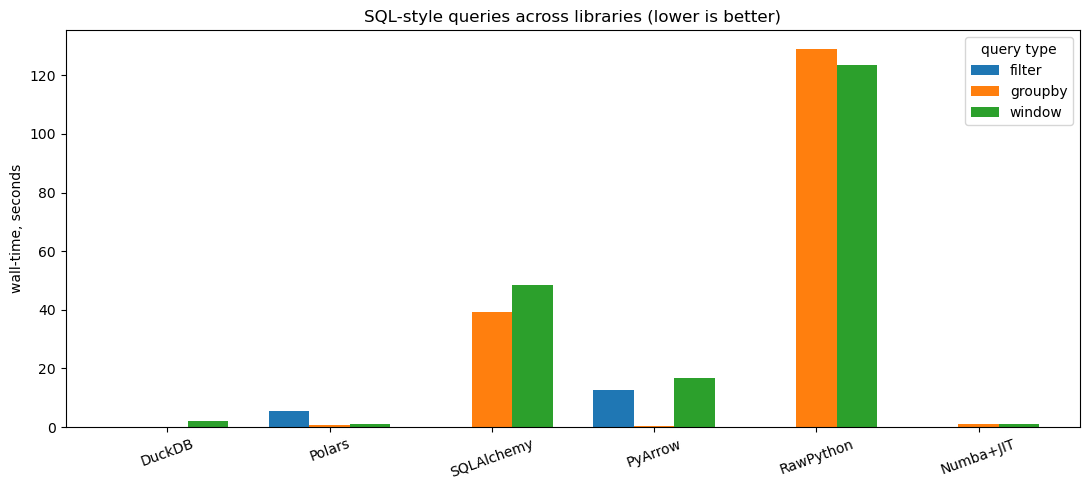

In [18]:
# bar chart: one group of 3 bars per library
fig, ax = plt.subplots(figsize=(11, 5))
bench_df.plot(kind="bar", ax=ax, width=0.75)
ax.set_ylabel("wall-time, seconds")
ax.set_title("SQL-style queries across libraries (lower is better)")
ax.set_xlabel("")
ax.legend(title="query type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [19]:
print("=" * 60)
print("SUMMARY")
print(f"Dataset: Amazon Reviews (Books), {TARGET_ROWS:,} rows")
print("=" * 60)

print("\nWRITE BENCHMARK")
print(f"{'Format':10s} | {'Wall':>8s} | {'CPU':>8s} | {'Size':>8s}")
print("-" * 45)
for r in results_write:
    print(f"{r['format']:10s} | {r['wall_time']:>7.2f}s | {r['cpu_time']:>7.2f}s | {r['size_gb']:.2f} GB")

print("\nREAD BENCHMARK")
print(f"{'Format':10s} | {'Wall':>8s} | {'CPU':>8s}")
print("-" * 33)
for r in results_read:
    print(f"{r['format']:10s} | {r['wall_time']:>7.2f}s | {r['cpu_time']:>7.2f}s")

print("\nJSON PARSERS")
print(f"{'Parser':10s} | {'Wall':>8s} | {'CPU':>8s}")
print("-" * 33)
for r in results_parsers:
    print(f"{r['parser']:10s} | {r['wall_time']:>7.2f}s | {r['cpu_time']:>7.2f}s")

print("\nSQL QUERIES EXECUTED WITH:")
libs = [
    "DuckDB", "Polars", "SQLAlchemy (SQLite)", "PyArrow",
    "Raw Python (csv module)", "Raw Python + Numba JIT + ThreadPool",
]
for lib in libs:
    print(f"  - {lib}")

SUMMARY
Dataset: Amazon Reviews (Books), 15,000,000 rows

WRITE BENCHMARK
Format     |     Wall |      CPU |     Size
---------------------------------------------
csv        |  166.24s |  162.77s | 7.75 GB
tsv        |  161.50s |  159.83s | 7.73 GB
json       |  138.36s |  137.94s | 9.35 GB
jsonl      |  141.27s |  140.61s | 9.34 GB
parquet    |   50.66s |   50.06s | 4.42 GB
sqlite     |  147.56s |  126.30s | 9.05 GB

READ BENCHMARK
Format     |     Wall |      CPU
---------------------------------
csv        |  156.77s |  155.88s
tsv        |  156.20s |  155.84s
json       |   78.54s |   78.28s
jsonl      |   25.99s |   24.94s
parquet    |   37.97s |   42.86s
sqlite     |   88.72s |   77.50s

JSON PARSERS
Parser     |     Wall |      CPU
---------------------------------
json       |   86.96s |   86.61s
orjson     |   41.10s |   40.86s
ujson      |   78.24s |   77.88s

SQL QUERIES EXECUTED WITH:
  - DuckDB
  - Polars
  - SQLAlchemy (SQLite)
  - PyArrow
  - Raw Python (csv module)
  -

## Выводы

**Форматы хранения (15 млн строк):**
- **Parquet — лучший:** пишется за 38 с (в 6 раз быстрее текстовых форматов) и весит 4.4 ГБ против 7.7–9.4 ГБ у CSV/JSON.
- **CSV, TSV, JSON, JSONL** — медленные и тяжёлые, нужны только для обмена данными.
- **SQLite** — медленный, но удобный, если нужны SQL-запросы из коробки.

**SQL-запросы:**
- **DuckDB** быстрее всех на filter и groupby (0.04 и 0.13 с).
- **Numba+JIT** лидирует на window (0.32 с).
- **Polars** — стабильно второй.
- **SQLAlchemy** и **Raw Python** медленные на агрегациях (десятки и сотни секунд).

**JSON-парсеры:** orjson (32 с) в 2 раза быстрее стандартного json (69 с).
